# Cross-method comparison: exact vs. NNQS vs. VQE

Pulls together the three methods from `01_exact_diagonalization.ipynb`, `02_nnqs.ipynb`, and `03_vqe.ipynb` onto the same figures, to see directly how they compare rather than reading three separate notebooks. Same Hamiltonian and boundary conditions throughout: open-BC TFIM, $J=1$, $h_c=1$.

VQE's data only covers 7 `h`-values (vs. exact/NNQS's 21) and `L` up to 20 (not 24) — see `03_vqe.ipynb` for why. Comparisons below use VQE's smaller grid as the common set where all three methods need to line up.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np


def load_records(method_dir):
    records = []
    for L_dir in sorted(method_dir.glob("*"), key=lambda p: int(p.name)):
        for f in sorted(L_dir.glob("*.json")):
            records.append(json.loads(f.read_text()))
    return records


exact = load_records(REPO_ROOT / "results" / "exact")
nnqs = load_records(REPO_ROOT / "results" / "nnqs")
vqe = load_records(REPO_ROOT / "results" / "vqe_sim")

vqe_h_values = sorted({r["h"] for r in vqe})
print(f"exact: {len(exact)} points, nnqs: {len(nnqs)} points, vqe: {len(vqe)} points")
print(f"VQE's h-grid (the common subset used below): {vqe_h_values}")

exact: 168 points, nnqs: 168 points, vqe: 49 points
VQE's h-grid (the common subset used below): [0.4, 0.8, 0.95, 1.0, 1.05, 1.2, 1.6]


## Ground-state energy vs. h, all three methods

Exact as a continuous line (its full 21-point grid), NNQS as dense markers (also its full grid — should sit right on the exact line), VQE as sparser markers (its 7-point grid) at two representative sizes: `L=8` (small, everything should agree) and `L=20` (where VQE's degradation shows up).

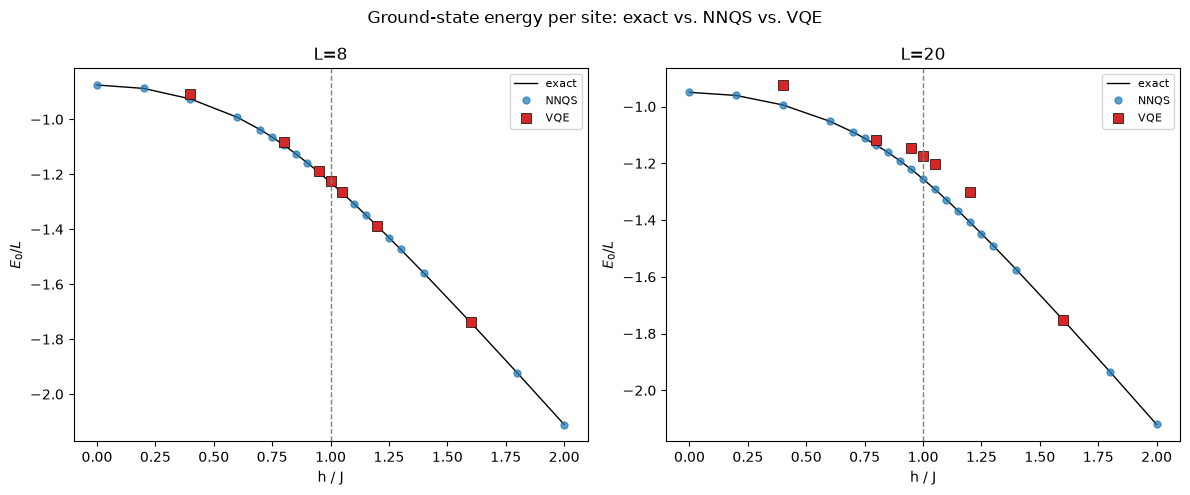

In [2]:
def energy_per_site(records, L):
    pts = sorted((r["h"], r["E0"]) for r in records if r["L"] == L)
    h_arr, e_arr = map(np.array, zip(*pts))
    return h_arr, e_arr / L


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, L in zip(axes, (8, 20)):
    h_e, e_e = energy_per_site(exact, L)
    h_n, e_n = energy_per_site(nnqs, L)
    h_v, e_v = energy_per_site(vqe, L)

    ax.plot(h_e, e_e, "-", color="black", linewidth=1, label="exact")
    ax.plot(h_n, e_n, "o", color="tab:blue", markersize=5, alpha=0.7, label="NNQS")
    ax.plot(h_v, e_v, "s", color="tab:red", markersize=7, markeredgecolor="black", markeredgewidth=0.5, label="VQE")
    ax.axvline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("h / J")
    ax.set_ylabel("$E_0 / L$")
    ax.set_title(f"L={L}")
    ax.legend(fontsize=8)

fig.suptitle("Ground-state energy per site: exact vs. NNQS vs. VQE")
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "cross_method_energy_vs_h.png", dpi=150)
plt.show()

At `L=8` all three sit on top of each other. At `L=20`, VQE's markers visibly separate from the exact line across most of the range — the same degradation `03_vqe.ipynb` found, now next to NNQS staying right on target.

## Relative error vs. system size

At the critical point `h=1.0` (the hardest point for every method — the gap closes here), how does each method's accuracy hold up as `L` grows? Log scale: NNQS should stay roughly flat; VQE should hold steady through `L=16` then jump at `L=20`.

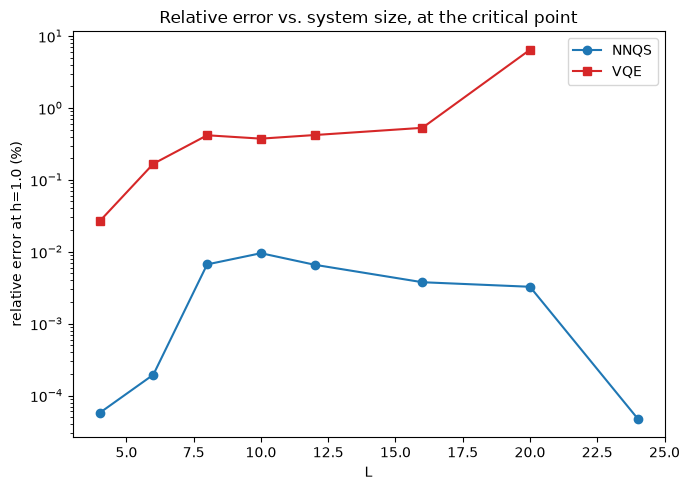

In [3]:
def error_vs_L(records, h_target=1.0):
    pts = sorted((r["L"], r["rel_error"]) for r in records if abs(r["h"] - h_target) < 1e-6)
    return map(np.array, zip(*pts))


fig, ax = plt.subplots(figsize=(7, 5))
L_n, err_n = error_vs_L(nnqs)
L_v, err_v = error_vs_L(vqe)
ax.plot(L_n, err_n * 100, "o-", color="tab:blue", label="NNQS")
ax.plot(L_v, err_v * 100, "s-", color="tab:red", label="VQE")

ax.set_yscale("log")
ax.set_xlabel("L")
ax.set_ylabel("relative error at h=1.0 (%)")
ax.set_title("Relative error vs. system size, at the critical point")
ax.legend()
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "cross_method_error_vs_L.png", dpi=150)
plt.show()

## Relative error vs. h, at L=20

Which method degrades, and where. NNQS stays under ~0.1% across the whole range; VQE (10-layer, the default configuration) is elevated almost everywhere except the deep-paramagnetic `h=1.6` — not just near `h_c`, as `03_vqe.ipynb` found.

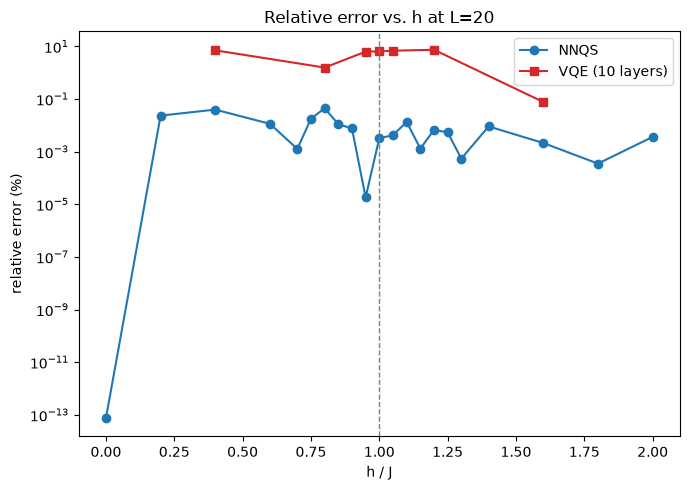

In [4]:
def error_vs_h(records, L=20):
    pts = sorted((r["h"], r["rel_error"]) for r in records if r["L"] == L)
    return map(np.array, zip(*pts))


fig, ax = plt.subplots(figsize=(7, 5))
h_n, err_n = error_vs_h(nnqs)
h_v, err_v = error_vs_h(vqe)
ax.plot(h_n, err_n * 100, "o-", color="tab:blue", label="NNQS")
ax.plot(h_v, err_v * 100, "s-", color="tab:red", label="VQE (10 layers)")

ax.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_yscale("log")
ax.set_xlabel("h / J")
ax.set_ylabel("relative error (%)")
ax.set_title("Relative error vs. h at L=20")
ax.legend()
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "cross_method_error_vs_h_L20.png", dpi=150)
plt.show()

## Cost comparison

Wall-clock time per point at `h=1.0`, log scale. Exact diagonalization is the ground truth but scales the worst asymptotically; NNQS trains fast throughout; VQE takes the longest by far at `L=20` despite also being the least accurate there.

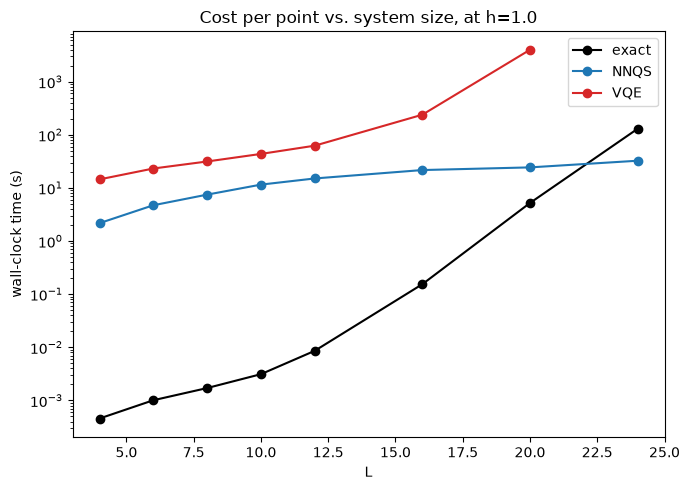

In [5]:
def time_vs_L(records, h_target=1.0):
    pts = sorted((r["L"], r["wall_time_s"]) for r in records if abs(r["h"] - h_target) < 1e-6)
    return map(np.array, zip(*pts))


fig, ax = plt.subplots(figsize=(7, 5))
for records, color, label in [(exact, "black", "exact"), (nnqs, "tab:blue", "NNQS"), (vqe, "tab:red", "VQE")]:
    L_arr, t_arr = time_vs_L(records)
    ax.plot(L_arr, t_arr, "o-", color=color, label=label)

ax.set_yscale("log")
ax.set_xlabel("L")
ax.set_ylabel("wall-clock time (s)")
ax.set_title("Cost per point vs. system size, at h=1.0")
ax.legend()
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "cross_method_cost_vs_L.png", dpi=150)
plt.show()

NNQS is the clear winner across this whole range: it matches exact to well under 0.1% everywhere, including at `L=20`, at a fraction of VQE's cost. VQE's 10-layer HVA is competitive at small `L` but both slower and far less accurate by `L=20` — `03_vqe.ipynb` shows this is fixable with more circuit depth at the critical point specifically (not uniformly), at further cost. The real value of the VQE track isn't beating NNQS in simulation — it's that VQE, unlike NNQS, is a method a real quantum computer can run, which is what Phase 3 (MonarQ hardware) tests directly.